# Limak Cimento — Carbon Footprint & Cost Optimization
## Project Overview

This notebook explores Limak Cimento's ESG performance data (2021–2024)
extracted from official sustainability reports.

**Data sources:** Limak Cimento Sustainability Reports 2023 & 2024  
**Coverage:** Scope 1, 2, 3 emissions | Energy mix | Alternative fuel usage  
**Next step:** Optimization model → 02_Optimization.ipynb

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cement Industry Carbon Footprint & Cost Optimization

## Objective
Build an optimization model that minimizes CO₂ emissions and production costs 
in cement manufacturing by optimizing clinker ratio, alternative fuel usage, 
and carbon cost exposure.

## Data Sources
- EU ETS carbon prices: ember-climate.org
- Cement emission factors: GCCA Sustainability Guidelines
- Energy prices: IEA, Eurostat

In [2]:
# Limak Cimento ESG Data (2021-2024)
# Source: Limak Cimento Sustainability Reports 2023 & 2024

data = {
    'Year': [2021, 2022, 2023, 2024],
    
    # Emissions (ton CO2)
    'Scope1_tCO2': [8_416_832, 7_290_513, 7_138_623, 7_222_576],
    'Scope2_tCO2': [424_808, 362_822, 342_995, 344_263],
    'Scope3_tCO2': [None, 974_001, 774_076, 636_166],
    'Total_Emissions_tCO2': [8_841_640, 8_627_337, 8_255_695, 8_203_005],
    
    # Energy
    'Electricity_MWh': [871_968, 804_036, 801_349, 833_508],
    'Coal_ton': [1_195_450, 1_188_875, 973_952, 866_871],
    'Alt_Fuel_ton': [17_375, 29_900, 86_809, 148_515],
    'Alt_Fuel_pct': [0.78, 1.97, 7.56, 12.81],
}

df = pd.DataFrame(data)
df

,Year,Scope1_tCO2,Scope2_tCO2,Scope3_tCO2,Total_Emissions_tCO2,Electricity_MWh,Coal_ton,Alt_Fuel_ton,Alt_Fuel_pct
0,2021,8416832,424808,NaN,8841640,871968,1195450,17375,0.78
1,2022,7290513,362822,974001.0,8627337,804036,1188875,29900,1.97
2,2023,7138623,342995,774076.0,8255695,801349,973952,86809,7.56
3,2024,7222576,344263,636166.0,8203005,833508,866871,148515,12.81


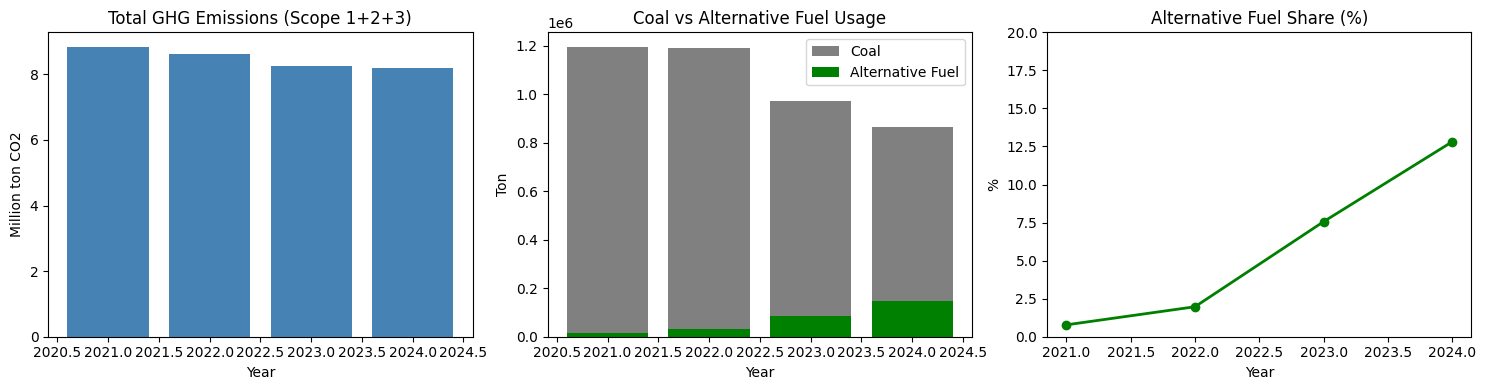

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Total Emissions
axes[0].bar(df['Year'], df['Total_Emissions_tCO2'] / 1_000_000, color='steelblue')
axes[0].set_title('Total GHG Emissions (Scope 1+2+3)')
axes[0].set_ylabel('Million ton CO2')
axes[0].set_xlabel('Year')

# 2. Coal vs Alternative Fuel
axes[1].bar(df['Year'], df['Coal_ton'], label='Coal', color='gray')
axes[1].bar(df['Year'], df['Alt_Fuel_ton'], label='Alternative Fuel', color='green', bottom=0)
axes[1].set_title('Coal vs Alternative Fuel Usage')
axes[1].set_ylabel('Ton')
axes[1].set_xlabel('Year')
axes[1].legend()

# 3. Alternative Fuel Share
axes[2].plot(df['Year'], df['Alt_Fuel_pct'], marker='o', color='green', linewidth=2)
axes[2].set_title('Alternative Fuel Share (%)')
axes[2].set_ylabel('%')
axes[2].set_xlabel('Year')
axes[2].set_ylim(0, 20)

plt.tight_layout()
plt.savefig('limak_esg_overview.png', dpi=150)
plt.show()

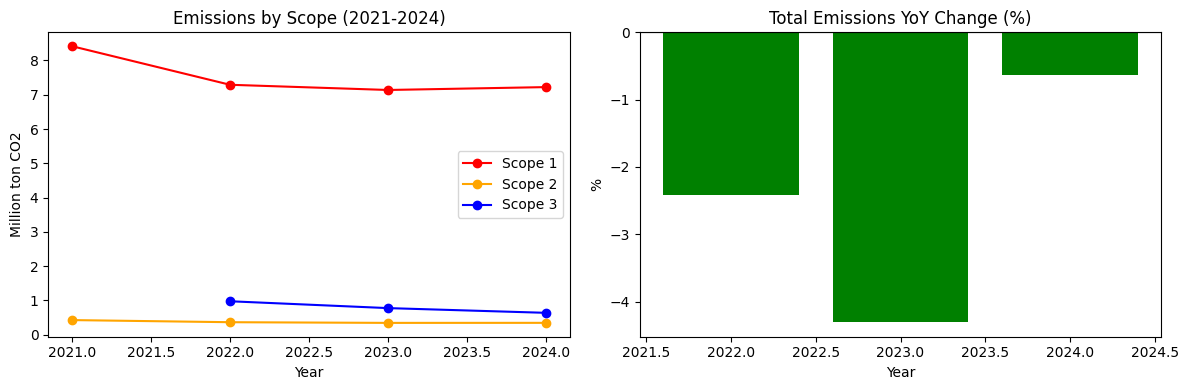

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Scope 1, 2, 3 breakdown
axes[0].plot(df['Year'], df['Scope1_tCO2'] / 1_000_000, marker='o', label='Scope 1', color='red')
axes[0].plot(df['Year'], df['Scope2_tCO2'] / 1_000_000, marker='o', label='Scope 2', color='orange')
axes[0].plot(df['Year'], df['Scope3_tCO2'] / 1_000_000, marker='o', label='Scope 3', color='blue')
axes[0].set_title('Emissions by Scope (2021-2024)')
axes[0].set_ylabel('Million ton CO2')
axes[0].set_xlabel('Year')
axes[0].legend()

# 2. Year-over-year % change in total emissions
df['Emission_YoY_pct'] = df['Total_Emissions_tCO2'].pct_change() * 100
axes[1].bar(df['Year'][1:], df['Emission_YoY_pct'][1:], 
            color=['red' if x > 0 else 'green' for x in df['Emission_YoY_pct'][1:]])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Total Emissions YoY Change (%)')
axes[1].set_ylabel('%')
axes[1].set_xlabel('Year')

plt.tight_layout()
plt.savefig('limak_emissions_detail.png', dpi=150)
plt.show()

## Key Findings from EDA

- **Total emissions declined** from 8.84M ton CO2 (2021) to 8.20M ton CO2 (2024) — a **7.2% reduction**
- **Scope 1** dominates at ~88% of total emissions
- **Alternative fuel usage** grew dramatically: 17K ton (2021) → 149K ton (2024) — nearly **9x increase**
- **Coal consumption** decreased from 1.19M ton to 0.87M ton — a **27% reduction**
- **2030 target**: Alternative fuel share to reach 61% (currently at 12.81%)

### Next Step: Optimization Model
Build a model to find the optimal mix of clinker ratio, alternative fuel usage, 
and energy sources to minimize CO2 emissions while controlling costs.

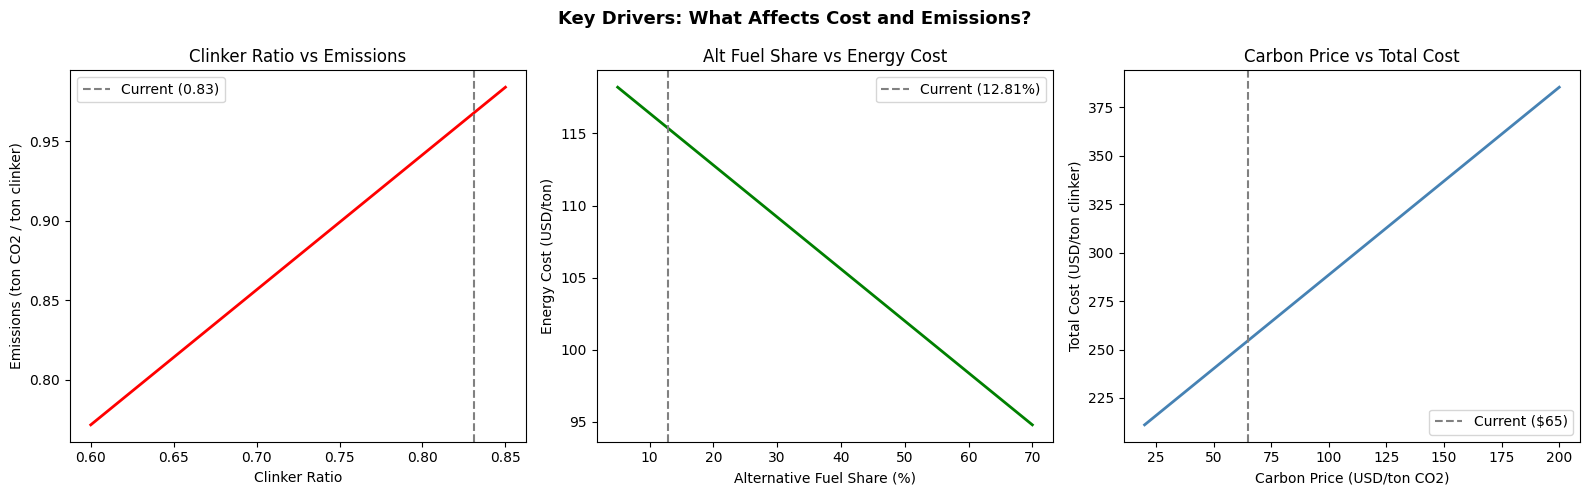

In [6]:
# === EDA UPGRADE: Decision-relevant plots ===

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Clinker ratio vs Emissions
clinker_vals = np.linspace(0.60, 0.85, 100)
emissions_vals = clinker_vals * 0.85 + (1 - 0.1281) * 0.3
axes[0].plot(clinker_vals, emissions_vals, color='red', linewidth=2)
axes[0].axvline(x=0.8313, color='gray', linestyle='--', label='Current (0.83)')
axes[0].set_title('Clinker Ratio vs Emissions')
axes[0].set_xlabel('Clinker Ratio')
axes[0].set_ylabel('Emissions (ton CO2 / ton clinker)')
axes[0].legend()

# 2. Alt fuel share vs Energy cost
alt_fuel_vals = np.linspace(0.05, 0.70, 100)
energy_price = 120
energy_costs = (1 - alt_fuel_vals) * energy_price + alt_fuel_vals * (energy_price * 0.7)
axes[1].plot(alt_fuel_vals * 100, energy_costs, color='green', linewidth=2)
axes[1].axvline(x=12.81, color='gray', linestyle='--', label='Current (12.81%)')
axes[1].set_title('Alt Fuel Share vs Energy Cost')
axes[1].set_xlabel('Alternative Fuel Share (%)')
axes[1].set_ylabel('Energy Cost (USD/ton)')
axes[1].legend()

# 3. Carbon price vs Total cost
carbon_prices = np.linspace(20, 200, 100)
co2_per_ton = (1 - 0.1281) * 0.3 + 0.8313 * 0.85
total_costs = 254.70 + (carbon_prices - 65) * co2_per_ton
axes[2].plot(carbon_prices, total_costs, color='steelblue', linewidth=2)
axes[2].axvline(x=65, color='gray', linestyle='--', label='Current ($65)')
axes[2].set_title('Carbon Price vs Total Cost')
axes[2].set_xlabel('Carbon Price (USD/ton CO2)')
axes[2].set_ylabel('Total Cost (USD/ton clinker)')
axes[2].legend()

plt.suptitle('Key Drivers: What Affects Cost and Emissions?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('limak_eda_drivers.png', dpi=150)
plt.show()